# 03 — Late deliveries (Olist)

**Question:** which origin→destination routes / seller areas miss the promised window most, and is lateness getting worse?

**Late definition:** `order_delivered_customer_date` > `order_estimated_delivery_date`, **delivered orders only**.

**Grain:** one order in `olist_orders_dataset`; join sellers/customers for states.

Notion: Project 03 — Late deliveries


## 1. Imports + paths


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Optional later (Quest stack): SQL via sqlalchemy / psycopg2 once CSVs are in Postgres
# from sqlalchemy import create_engine

DATA_DIR = Path(".").resolve()  # this project folder
DATA_DIR


PosixPath('/Users/sergiocastillop/Desktop/analytics_practice/projects/03-late_deliveries')

## 2. Load CSVs

Run after the Olist files are in `DATA_DIR`. If a file is missing, the cell will tell you which one.


In [2]:
required = {
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "customers": "olist_customers_dataset.csv",
}

orders = pd.read_csv(DATA_DIR / required["orders"])
order_items = pd.read_csv(DATA_DIR / required["order_items"])
sellers = pd.read_csv(DATA_DIR / required["sellers"])
customers = pd.read_csv(DATA_DIR / required["customers"])

for name, df in {
    "orders": orders,
    "order_items": order_items,
    "sellers": sellers,
    "customers": customers,
}.items():
    print(f"{name}: {df.shape}")


orders: (99441, 8)
order_items: (112650, 7)
sellers: (3095, 4)
customers: (99441, 5)


## 3. First 10-minute profile (`orders`)

Write into Notion: shape, key dtypes, nulls on delivery date columns, value counts of `order_status`.


In [3]:
print("orders shape:", orders.shape)
print("\ndtypes:\n", orders.dtypes)
print("\nnull counts (delivery-related):")
date_cols = [
    c
    for c in [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ]
    if c in orders.columns
]
print(orders[date_cols].isna().sum())
print("\norder_status counts:")
print(orders["order_status"].value_counts(dropna=False))


orders shape: (99441, 8)

dtypes:
 order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

null counts (delivery-related):
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

order_status counts:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


## 4. Parse dates + delivered-only slice + late flag

Decision to log: late only on delivered; compare customer delivery date to estimated date.


In [4]:
# Parse date columns (Olist ships them as strings)
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

delivered = orders[orders["order_status"] == "delivered"].copy()

delivered["is_late"] = (
    delivered["order_delivered_customer_date"]
    > delivered["order_estimated_delivery_date"]
)

# Sanity: drop rows missing either date before rate (count them first)
n_missing_dates = delivered[
    delivered["order_delivered_customer_date"].isna()
    | delivered["order_estimated_delivery_date"].isna()
].shape[0]

late_eligible = delivered.dropna(
    subset=["order_delivered_customer_date", "order_estimated_delivery_date"]
)

overall_late_rate = late_eligible["is_late"].mean()

print("orders total:", len(orders))
print("delivered:", len(delivered))
print("delivered with missing delivery/estimate dates:", n_missing_dates)
print("late-eligible delivered:", len(late_eligible))
print("overall late rate:", round(overall_late_rate, 4), f"({overall_late_rate:.2%})")
print("late count:", int(late_eligible["is_late"].sum()))


orders total: 99441
delivered: 96478
delivered with missing delivery/estimate dates: 8
late-eligible delivered: 96470
overall late rate: 0.0811 (8.11%)
late count: 7826


## 5. Notion paste (after you run §3–4)

Fill Data toggles / First 10-min profile:

- Grain: one **delivered** order for the late flag
- Rows: orders / delivered / late-eligible (paste numbers)
- Nulls: missing delivery or estimate dates among delivered
- Sanity: overall late %

**Decision log row:** keep undelivered out of late rate; count missing dates before dropping.

---

## Next (you write these — done bar)

Do **not** skip to charts until overall late % is in Notion.

1. SQL or pandas: late rate by **customer_state → seller_state** (or origin→destination — confirm which columns you use), top 15 by volume  
2. Late by seller state / top sellers with **n** visible  
3. Monthly late-rate trend chart  
4. Top late corridors chart  
5. Write-up: finding · caveat · ops rec


In [5]:
from sqlalchemy import create_engine, text

engine = create_engine("postgresql+psycopg2://postgres@127.0.0.1:5432/olist")
with engine.connect() as conn:
    print(conn.execute(text("SELECT current_database(), current_user")).fetchone())

('olist', 'postgres')


In [6]:
import pandas as pd

orders = pd.read_csv("olist_orders_dataset.csv")
orders.to_sql("orders", engine, if_exists="replace", index=False)

with engine.connect() as conn:
    print(conn.execute(text("SELECT COUNT(*) FROM orders")).scalar())

99441


In [7]:
order_items = pd.read_csv("olist_order_items_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")

order_items.to_sql("order_items", engine, if_exists="replace", index=False)
sellers.to_sql("sellers", engine, if_exists="replace", index=False)
customers.to_sql("customers", engine, if_exists="replace", index=False)

with engine.connect() as conn:
    for t in ("orders", "order_items", "sellers", "customers"):
        n = conn.execute(text(f"SELECT COUNT(*) FROM {t}")).scalar()
        print(f"We have {n} rows in {t}")

We have 99441 rows in orders
We have 112650 rows in order_items
We have 3095 rows in sellers
We have 99441 rows in customers


In [8]:
sql = """
SELECT
  COUNT(*) AS late_eligible,
  COUNT(*) FILTER (
    WHERE order_delivered_customer_date > order_estimated_delivery_date
  ) AS late_orders,
  ROUND(
    100.0 * COUNT(*) FILTER (
      WHERE order_delivered_customer_date > order_estimated_delivery_date
    ) / COUNT(*),
    2
  ) AS late_rate_pct
FROM orders
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL
  AND order_estimated_delivery_date IS NOT NULL;
"""

with engine.connect() as conn:
    print(conn.execute(text(sql)).fetchone())

(96470, 7826, Decimal('8.11'))


In [16]:
sql_corridors = """
WITH base AS (
  SELECT
    s.seller_state,
    c.customer_state,
    o.order_id,
    (o.order_delivered_customer_date > o.order_estimated_delivery_date) AS is_late,
    -- FIX 1 + 2: tag each row here, where o. still exists
    CASE
      WHEN o.order_purchase_timestamp::timestamp >= '2018-02-01'
       AND o.order_purchase_timestamp::timestamp <  '2018-04-01'
      THEN 'spike' ELSE 'normal'
    END AS period
  FROM orders o
  JOIN customers c ON c.customer_id = o.customer_id
  JOIN order_items oi ON oi.order_id = o.order_id
  JOIN sellers s ON s.seller_id = oi.seller_id
  WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
    AND o.order_estimated_delivery_date IS NOT NULL
),
-- one order can have several items/sellers; count each order once per corridor
per_order AS (
  SELECT
    seller_state,
    customer_state,
    period,                          -- FIX 3: just carry the tag through
    order_id,
    BOOL_OR(is_late) AS is_late
  FROM base
  GROUP BY seller_state, customer_state, period, order_id
)
SELECT
  seller_state,
  customer_state,
  period,                            -- FIX 4: select it...
  COUNT(*) AS n_orders,
  COUNT(*) FILTER (WHERE is_late) AS n_late,
  ROUND(100.0 * COUNT(*) FILTER (WHERE is_late) / COUNT(*), 2) AS late_rate_pct
FROM per_order
GROUP BY seller_state, customer_state, period   -- ...and group by it
HAVING COUNT(*) >= 100                          -- FIX 5: replaces LIMIT 15
ORDER BY seller_state, customer_state, period;
"""

corr_period = pd.read_sql(text(sql_corridors), engine)
corr_period[
    (corr_period["period"] == "spike") &
    (corr_period["seller_state"] != "SP")
]

,seller_state,customer_state,period,n_orders,n_late,late_rate_pct
9,MG,MG,spike,180,9,5.00
13,MG,RJ,spike,131,25,19.08
17,MG,SP,spike,279,28,10.04
21,PR,MG,spike,167,23,13.77
23,PR,PR,spike,123,4,3.25
25,PR,RJ,spike,203,74,36.45
27,PR,RS,spike,107,8,7.48
30,PR,SP,spike,573,35,6.11
35,RJ,RJ,spike,126,5,3.97
38,RJ,SP,spike,164,56,34.15


In [10]:
sql_seller_state = """
WITH base AS (
  SELECT
    s.seller_state,
    o.order_id,
    (o.order_delivered_customer_date > o.order_estimated_delivery_date) AS is_late
  FROM orders o
  JOIN order_items oi ON oi.order_id = o.order_id
  JOIN sellers s ON s.seller_id = oi.seller_id
  WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
    AND o.order_estimated_delivery_date IS NOT NULL
),
per_order AS (
  SELECT
    seller_state,
    order_id,
    BOOL_OR(is_late) AS is_late
  FROM base
  GROUP BY seller_state, order_id
)
SELECT
  seller_state,
  COUNT(*) AS n_orders,
  COUNT(*) FILTER (WHERE is_late) AS n_late,
  ROUND(100.0 * COUNT(*) FILTER (WHERE is_late) / COUNT(*), 2) AS late_rate_pct
FROM per_order
GROUP BY seller_state
HAVING COUNT(*) >= 500   -- sample size: ignore tiny seller states
ORDER BY n_orders DESC;
"""

with engine.connect() as conn:
    for r in conn.execute(text(sql_seller_state)):
        print(r)

('SP', 68635, 6002, Decimal('8.74'))
('MG', 7733, 432, Decimal('5.59'))
('PR', 7512, 485, Decimal('6.46'))
('RJ', 4227, 355, Decimal('8.40'))
('SC', 3603, 215, Decimal('5.97'))
('RS', 1962, 84, Decimal('4.28'))
('DF', 808, 49, Decimal('6.06'))
('BA', 550, 32, Decimal('5.82'))


In [11]:
sql_seller_sample = """
WITH base AS (
  SELECT
    s.seller_id,
    s.seller_state,
    o.order_id,
    (o.order_delivered_customer_date > o.order_estimated_delivery_date) AS is_late
  FROM orders o
  JOIN order_items oi ON oi.order_id = o.order_id
  JOIN sellers s ON s.seller_id = oi.seller_id
  WHERE o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL
    AND o.order_estimated_delivery_date IS NOT NULL
), 
per_order AS (
  SELECT
    seller_state,
    seller_id,
    order_id,
    BOOL_OR(is_late) AS is_late
  FROM base
  GROUP BY seller_state, seller_id, order_id
)
SELECT
  seller_state,
  seller_id,
  COUNT(*) AS n_orders,
  COUNT(*) FILTER (WHERE is_late) AS n_late,
  ROUND(100.0 * COUNT(*) FILTER (WHERE is_late) / COUNT(*), 2) AS late_rate_pct
FROM per_order
GROUP BY seller_state, seller_id
HAVING COUNT(*) >= 50
ORDER BY late_rate_pct DESC, n_orders DESC
LIMIT 15;
"""

with engine.connect() as conn:
    for r in conn.execute(text(sql_seller_sample)):
        print(r)

('PR', '54965bbe3e4f07ae045b90b0b8541f52', 73, 22, Decimal('30.14'))
('SP', 'a49928bcdf77c55c6d6e05e09a9b4ca5', 96, 25, Decimal('26.04'))
('SP', 'beadbee30901a7f61d031b6b686095ad', 64, 16, Decimal('25.00'))
('MA', '06a2c3af7b3aee5d69171b0e14f0ee87', 389, 90, Decimal('23.14'))
('SP', 'cac4c8e7b1ca6252d8f20b2fc1a2e4af', 74, 17, Decimal('22.97'))
('SP', '1ca7077d890b907f89be8c954a02686a', 108, 24, Decimal('22.22'))
('SP', '6039e27294dc75811c0d8a39069f52c0', 63, 14, Decimal('22.22'))
('SC', '712e6ed8aa4aa1fa65dab41fed5737e4', 77, 17, Decimal('22.08'))
('SP', 'ea566164622c6b439516ab18062c42cd', 50, 11, Decimal('22.00'))
('SP', 'd13e50eaa47b4cbe9eb81465865d8cfc', 66, 14, Decimal('21.21'))
('SP', '2a261b5b644fa05f4f2700eb93544f2c', 51, 10, Decimal('19.61'))
('PR', '88460e8ebdecbfecb5f9601833981930', 246, 48, Decimal('19.51'))
('SP', 'e5a3438891c0bfdb9394643f95273d8e', 216, 40, Decimal('18.52'))
('SP', 'cd68562d3f44870c08922d380acae552', 122, 22, Decimal('18.03'))
('SP', '002100f778ceb8431b7a1

In [12]:
sql_monthly = """
SELECT
  DATE_TRUNC('month', order_purchase_timestamp::timestamp) AS month,
  COUNT(*) AS n_orders,
  COUNT(*) FILTER (
    WHERE order_delivered_customer_date > order_estimated_delivery_date
  ) AS n_late,
  ROUND(100.0 * COUNT(*) FILTER (
    WHERE order_delivered_customer_date > order_estimated_delivery_date
  ) / COUNT(*), 2) AS late_rate_pct
FROM orders
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL
  AND order_estimated_delivery_date IS NOT NULL
GROUP BY 1
HAVING COUNT(*) >= 500
ORDER BY 1;
"""

monthly = pd.read_sql(text(sql_monthly), engine)
monthly


,month,n_orders,n_late,late_rate_pct
0,2017-01-01,750,23,3.07
1,2017-02-01,1653,53,3.21
2,2017-03-01,2546,142,5.58
3,2017-04-01,2303,181,7.86
4,2017-05-01,3545,128,3.61
5,2017-06-01,3135,121,3.86
6,2017-07-01,3872,133,3.43
7,2017-08-01,4193,139,3.32
8,2017-09-01,4150,216,5.20
9,2017-10-01,4478,237,5.29


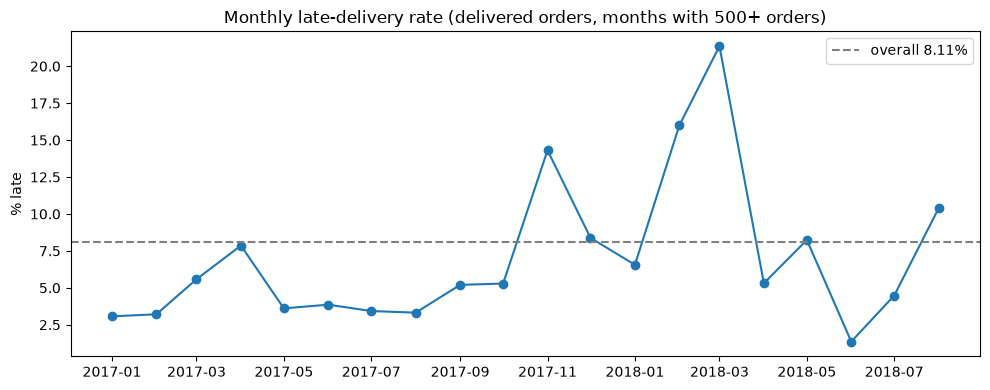

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly["month"], monthly["late_rate_pct"], marker="o")
ax.axhline(8.11, linestyle="--", color="gray", label="overall 8.11%")
ax.set_title("Monthly late-delivery rate (delivered orders, months with 500+ orders)")
ax.set_ylabel("% late")
ax.legend()
plt.tight_layout()
plt.show()

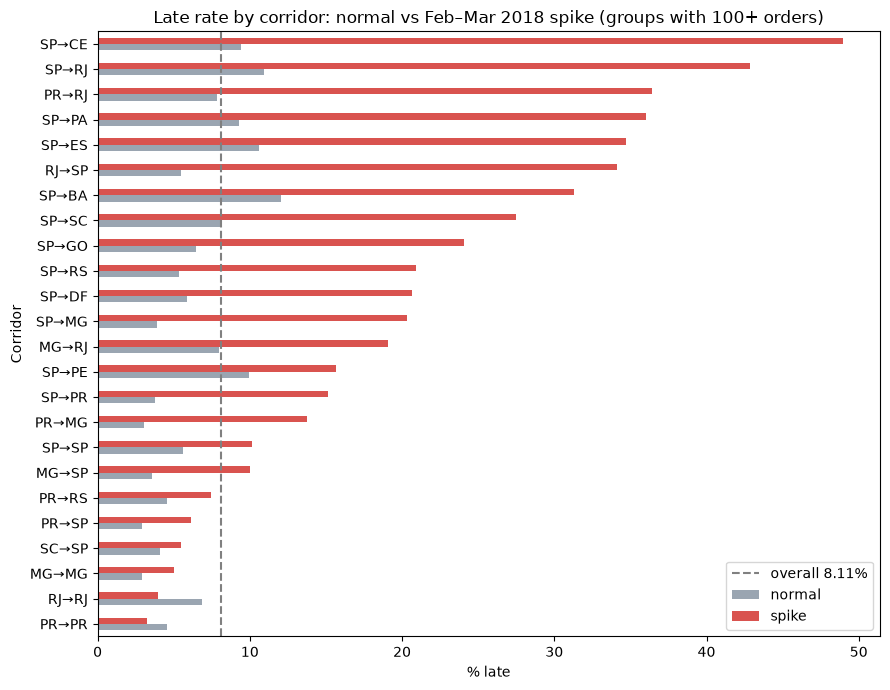

In [18]:
import matplotlib.pyplot as plt

# 1) reshape: one row per corridor, columns = normal / spike
corr_period["corridor"] = corr_period["seller_state"] + "→" + corr_period["customer_state"]
wide = corr_period.pivot(index="corridor", columns="period", values="late_rate_pct")

# 2) keep only corridors that have BOTH a normal and a spike rate
wide = wide.dropna()

# 3) sort so the worst spike ends up at the top of the chart
wide = wide.sort_values("spike")

# 4) plot
ax = wide[["normal", "spike"]].plot.barh(figsize=(9, 7), color=["#9aa5b1", "#d9534f"])
ax.axvline(8.11, linestyle="--", color="gray", label="overall 8.11%")
ax.set_xlabel("% late")
ax.set_ylabel("Corridor")
ax.set_title("Late rate by corridor: normal vs Feb–Mar 2018 spike (groups with 100+ orders)")
ax.legend()
plt.tight_layout()
plt.show()

In [19]:
wide.loc[["SP→CE", "SP→PA", "SP→ES", "SP→GO", "SP→DF", "SP→PE"]]

period,normal,spike
corridor,,
SP→CE,9.43,48.95
SP→PA,9.26,36.00
SP→ES,10.61,34.74
SP→GO,6.48,24.09
SP→DF,5.85,20.63
SP→PE,9.92,15.66
